In [3]:
from sqlalchemy import create_engine
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from dotenv import load_dotenv
import datetime
import os
import mplfinance as mpf
import re

In [4]:
load_dotenv()
# f"postgres+psycopg2://{[user]}:{[pass]}@{[host}:{[port]}/{[dbname]}"
engine = create_engine(
    f"postgresql+psycopg2://{os.getenv('POSTGRES_USER')}:{os.getenv('POSTGRES_PASSWORD')}"
    f"@{os.getenv('POSTGRES_HOST')}:{os.getenv('POSTGRES_PORT')}/{os.getenv('POSTGRES_DB')}"
)

In [5]:
query_min = "SELECT * FROM gold.active_1min ORDER BY bar_date, bar_time"
query_5min = "SELECT * FROM gold.active_5min ORDER BY bar_date, bar_time"
query_15min = "SELECT * FROM gold.active_15min ORDER BY bar_date, bar_time"
df_min = pd.read_sql(query_min,engine)
df_5min = pd.read_sql(query_5min,engine)
df_15min = pd.read_sql(query_15min,engine)

Swing Table

In [6]:
def get_swings(df):
    highs = df['high'].to_numpy()
    lows = df['low'].to_numpy()
    closes = df['close'].to_numpy()
    opens = df['open'].to_numpy()
    times = df['bar_time'].to_numpy()
    dates = df['bar_date'].to_numpy()
    
    swings = []
    start = None
    end = None
    direction = None
    threshold = 0
    
    for i in range(1,len(closes)):
        cur_direction = None
        if (closes[i] > closes[i-1]):
            cur_direction = 'UP'
        elif closes[i] < closes[i-1]:
            cur_direction = 'DOWN'
        else:
            cur_direction = "NONE"
        if dates[i] != dates[i-1]:
            swing = [
                dates[start],
                times[start],
                times[end],
                (times[end].hour * 60 + times[end].minute) - (times[start].hour * 60 + times[start].minute),
                max(highs[start],highs[end]),
                opens[start],
                closes[end],
                min(lows[start],lows[end]),
                direction,
                profit,
                drawdown
            ]
            swings.append(swing)
            direction = None
            continue
        
        if direction == None:
            direction = cur_direction
            start = i-1
            end = i
        elif ((direction == cur_direction) or abs(closes[i]-closes[i-1])<threshold):
            end = i
        else:
            profit=0;
            drawdown=0;
            if direction == 'UP':
                profit = abs(highs[end] - opens[start])
                drawdown = abs(opens[start] - lows[start])
            elif direction == 'DOWN':
                profit = abs(lows[end] - opens[start])
                drawdown = abs(opens[start] - lows[start])
            swing = [
                dates[start],
                times[start],
                times[end],
                (times[end].hour * 60 + times[end].minute) - (times[start].hour * 60 + times[start].minute),
                max(highs[start],highs[end]),
                opens[start],
                closes[end],
                min(lows[start],lows[end]),
                direction,
                profit,
                drawdown
            ]
            swings.append(swing)
            direction = cur_direction
            start = i-1
            end = i
    swing_columns=['date','time_start','time_end','duration','high','open', 'close','low','direction','profit','drawdown']
    df_swings = pd.DataFrame(swings,columns=swing_columns)
    df_swings['bucket_hour'] = df_swings['time_start'].apply(lambda t: datetime.time(t.hour,0,0))
    df_swings['bucket_30min'] = df_swings['time_start'].apply(
        lambda t: (datetime.datetime.min + datetime.timedelta(minutes=(t.hour*60+t.minute)//30*30)).time()
    )
    return df_swings

In [7]:
def statistical_analysis(df,bucket,target):
    groupby = df.groupby(bucket)[target]
    agg_swings = groupby.agg(['mean','median','std'])
    df['q1'] = groupby.transform(lambda x: x.quantile(.25))
    df['q3'] = groupby.transform(lambda x: x.quantile(.75))
    df_swings_IQR = df[(df[target]>df['q1']) & (df[target]<df['q3'])]
    agg_swings_IQR = df_swings_IQR.groupby(bucket)[target].agg(['mean','median','std'])
    return agg_swings, agg_swings_IQR

In [8]:
def bar_by_time(df, target, xlabel, ylabel):
    plt.figure(figsize=(10,3))
    plt.bar(df.index.astype(str), df[target])
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(ylabel+' By '+xlabel)
    ax = plt.gca()
    plt.xticks(rotation=45)
    plt.show()

findfont: Failed to find font weight medium, now using 400.


ESM25


findfont: Failed to find font weight semibold, now using 700.


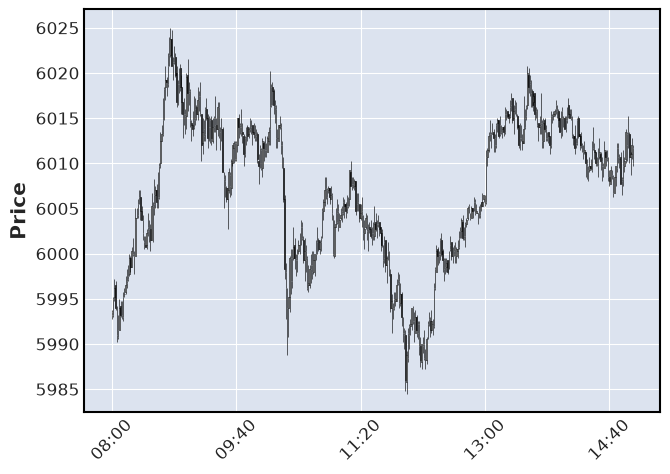

                        Open     High      Low    Close  Volume
datetime                                                       
2025-06-06 08:00:00  5993.25  5993.75  5992.75  5993.50   405.0
2025-06-06 08:01:00  5993.25  5995.25  5993.00  5995.00   886.0
2025-06-06 08:02:00  5995.25  5997.25  5994.75  5996.25  1424.0
2025-06-06 08:03:00  5996.50  5997.00  5993.75  5994.00   710.0
2025-06-06 08:04:00  5994.25  5994.25  5990.25  5991.00  1004.0
...                      ...      ...      ...      ...     ...
2025-06-06 14:55:00  6011.75  6015.25  6011.75  6013.50  5830.0
2025-06-06 14:56:00  6013.25  6013.50  6010.00  6010.75  5539.0
2025-06-06 14:57:00  6010.75  6011.25  6008.75  6011.00  4621.0
2025-06-06 14:58:00  6011.00  6012.75  6010.50  6012.00  4085.0
2025-06-06 14:59:00  6011.75  6012.00  6009.75  6010.00  6136.0

[420 rows x 5 columns]


In [9]:
def visualize_barchart(df, date):
    df_chart = df[df['bar_date'] == date].copy()
    print(df_chart.iloc[1]['contract'])
    df_chart['datetime'] = pd.to_datetime(df_chart['bar_date'].astype(str) + ' ' + df_chart['bar_time'].astype(str))
    df_chart = df_chart.set_index('datetime')
    df_chart = df_chart[['open','high','low','close','volume']]
    df_chart.columns = ['Open','High','Low','Close','Volume']
    mpf.plot(df_chart, type='candle', volume=False)
    print(df_chart)
visualize_barchart(df_min, datetime.date(2025, 6, 6))

In [10]:
VALID_MONTHS = {
    'ES': set('HMUZ'),
    'NQ': set('HMUZ')
}
EXPIRY_MONTH = {
    'F': 1,   # Jan
    'G': 2,   # Feb
    'H': 3,   # Mar
    'J': 4,   # Apr
    'K': 5,   # May
    'M': 6,   # Jun
    'N': 7,   # Jul
    'Q': 8,   # Aug
    'U': 9,   # Sep
    'V': 10,  # Oct
    'X': 11,  # Nov
    'Z': 12,  # Dec
}

class ContractDateRangeError(Exception):
    pass

class ContractNameError(Exception):
    pass

def validate_filename(contract):
    match = re.match(r'^([A-Z]{1,3})([FGHJKMNQUVXZ])(\d{2})$', contract)
    if not match:
        raise ContractNameError(f"Invalid contract format: {contract}, use CME format")
    root, month, year = match.groups()
    if root not in VALID_MONTHS:
        raise ContractNameError(f"Invalid contract: {root}, not in VALID_MONTHS")
    if month not in VALID_MONTHS[root]:
        raise ContractNameError(f"Invalid month for {root}: {month}, use CME format")

def third_monday(year, month):
    d = datetime.date(year, month, 1) # get the first of the month
    d += datetime.timedelta(days=(7 - d.weekday()) % 7) # get the first monday
    return d + datetime.timedelta(weeks=2) # add two weeks to get third monday

def validate_rollover_dates(contract, min_date, max_date):
    match = re.match(r'^([A-Z]{1,3})([FGHJKMNQUVXZ])(\d{2})$', contract)
    root, month_code, year = match.groups()
    exp_month = EXPIRY_MONTH[month_code]
    year = 2000 + int(year)

    # contract_month: 3=Mar, 6=Jun, 9=Sep, 12=Dec
    roll_month = exp_month - 3
    roll_year = year
    if roll_month <= 0:
        roll_month += 12
        roll_year -= 1
    start = third_monday(roll_year, roll_month)

    next_month = exp_month
    next_year = year
    next_roll_month = next_month
    next_roll_year = next_year
    end = third_monday(next_roll_year, next_roll_month) - datetime.timedelta(days=1)
    print(start,end)
    if not (min_date >= start and max_date <= end):
        raise ContractDateRangeError(f"Invalid date range for {contract}: must be between {start} - {end}")
validate_rollover_dates('ESM25',datetime.date(2025,3,17),datetime.date(2025,6,15))


2025-03-17 2025-06-15


1 Minute Chart

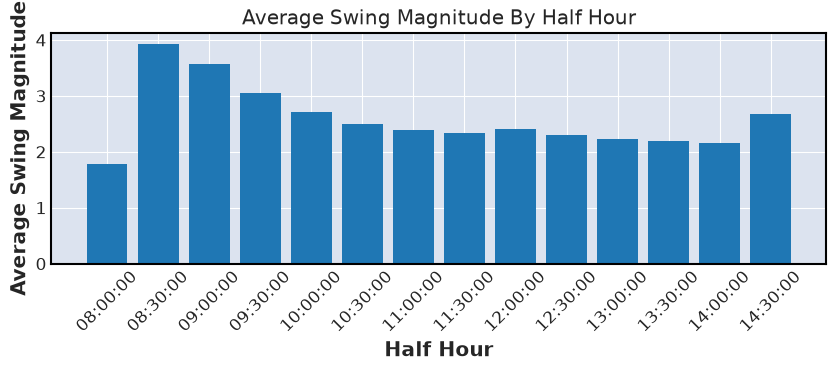

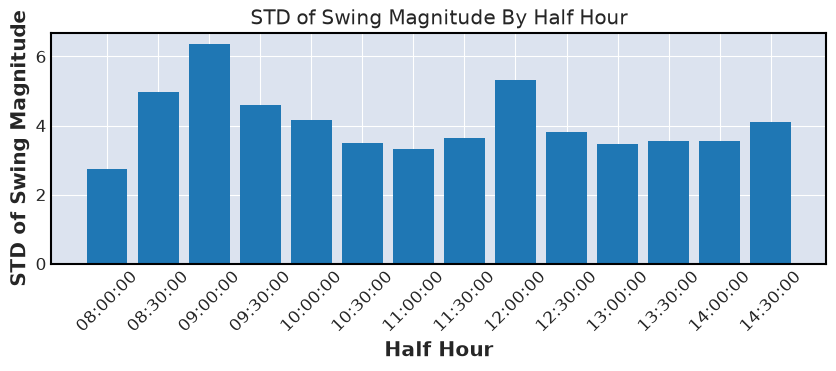

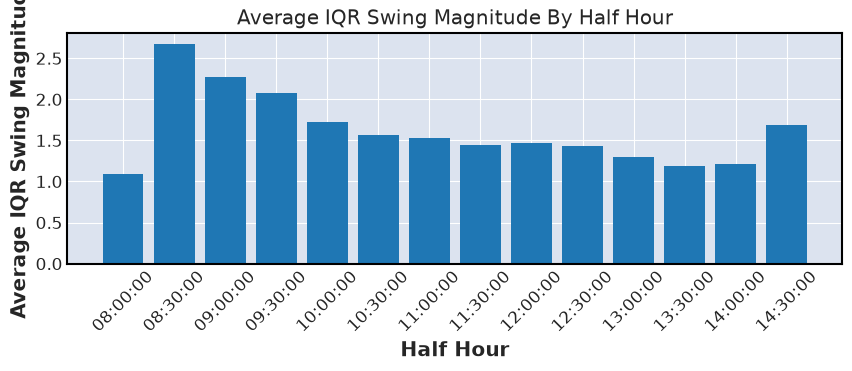

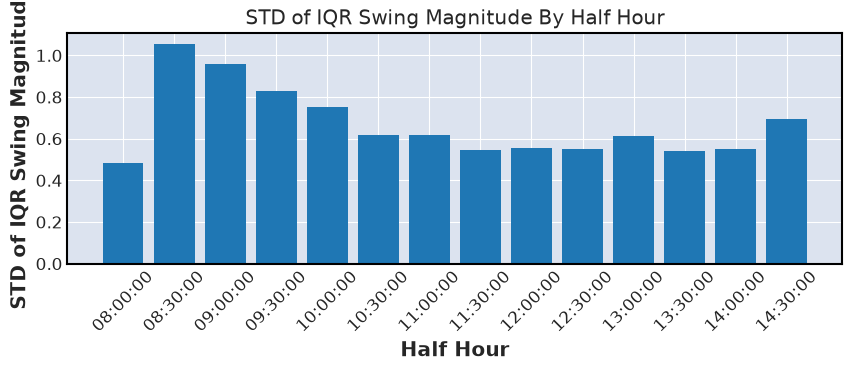

In [14]:
df_swing_min = get_swings(df_min)
agg_min_30b, agg_min_30b_IQR = statistical_analysis(df_swing_min,'bucket_30min','profit')
bar_by_time(agg_min_30b,'mean','Half Hour','Average Swing Magnitude')
bar_by_time(agg_min_30b,'std','Half Hour','STD of Swing Magnitude')
bar_by_time(agg_min_30b_IQR,'mean','Half Hour','Average IQR Swing Magnitude')
bar_by_time(agg_min_30b_IQR,'std','Half Hour','STD of IQR Swing Magnitude')

5 Minute Chart

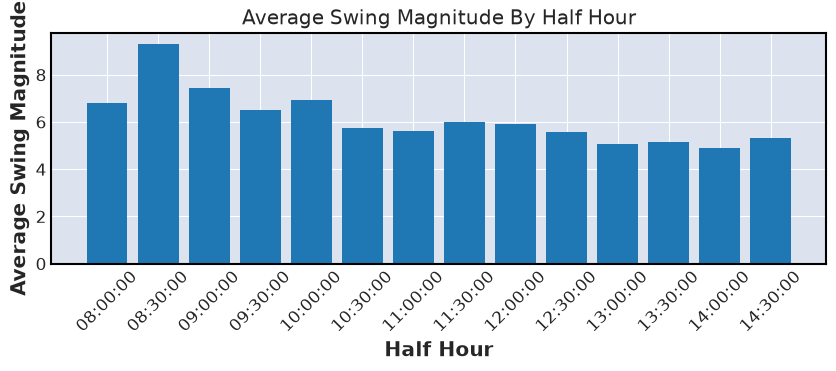

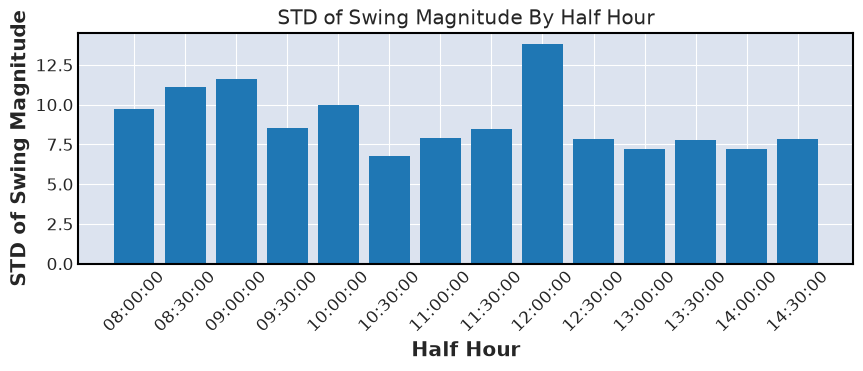

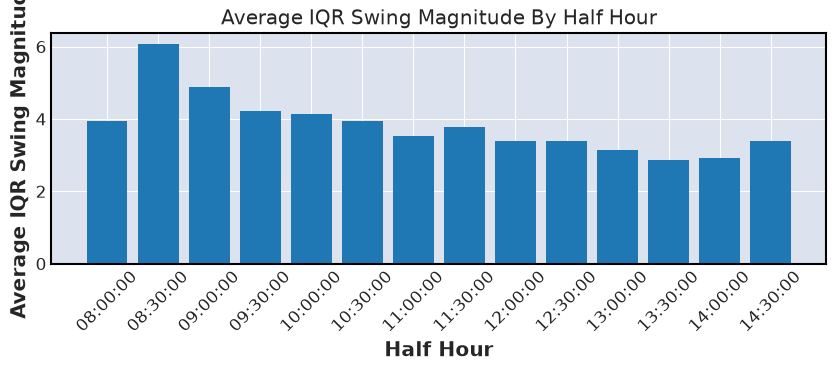

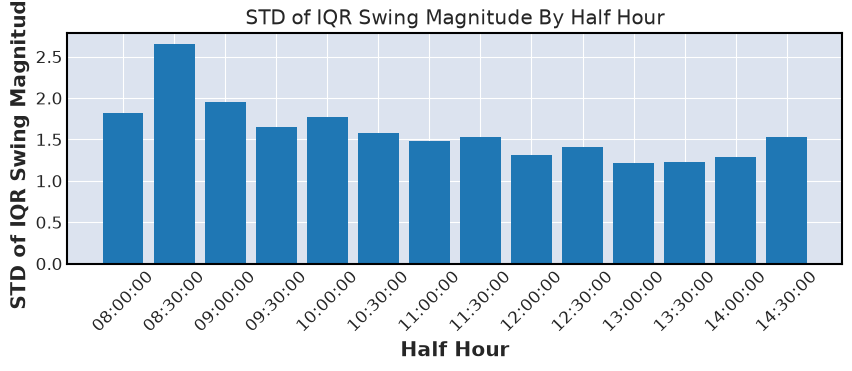

In [19]:
df_swing_5min = get_swings(df_5min)
agg_5min_30b, agg_5min_30b_IQR = statistical_analysis(df_swing_5min,'bucket_30min','profit')
bar_by_time(agg_5min_30b,'mean','Half Hour','Average Swing Magnitude')
bar_by_time(agg_5min_30b,'std','Half Hour','STD of Swing Magnitude')
bar_by_time(agg_5min_30b_IQR,'mean','Half Hour','Average IQR Swing Magnitude')
bar_by_time(agg_5min_30b_IQR,'std','Half Hour','STD of IQR Swing Magnitude')

15 Minute Chart

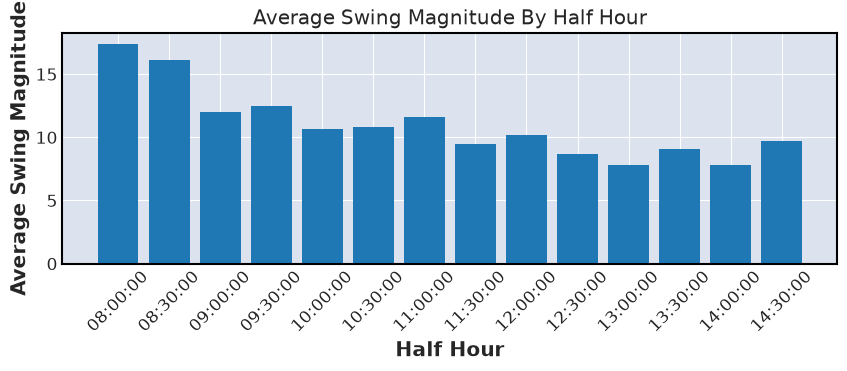

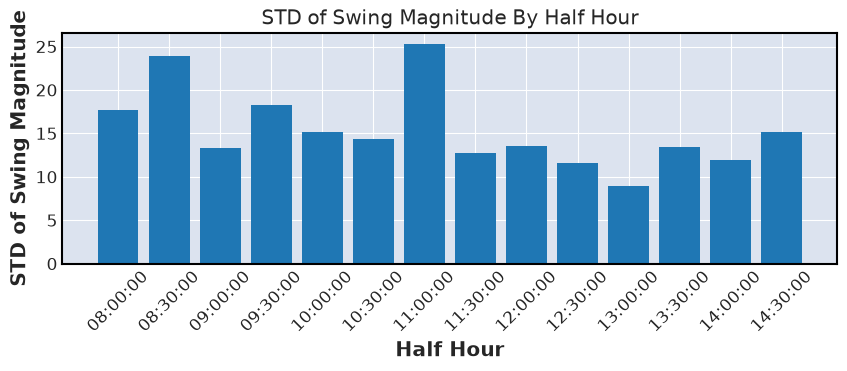

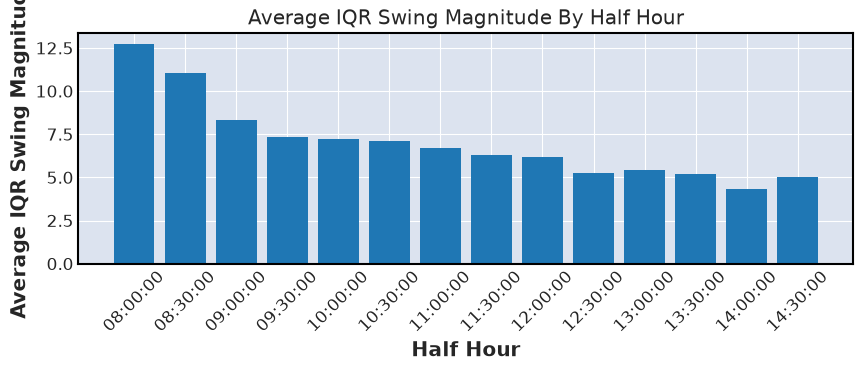

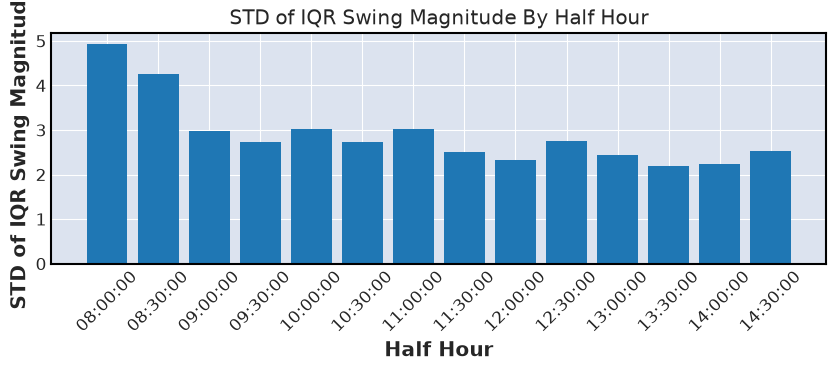

In [20]:
df_swing_15min = get_swings(df_15min)
agg_15min_30b, agg_15min_30b_IQR = statistical_analysis(df_swing_15min,'bucket_30min','profit')
bar_by_time(agg_15min_30b,'mean','Half Hour','Average Swing Magnitude')
bar_by_time(agg_15min_30b,'std','Half Hour','STD of Swing Magnitude')
bar_by_time(agg_15min_30b_IQR,'mean','Half Hour','Average IQR Swing Magnitude')
bar_by_time(agg_15min_30b_IQR,'std','Half Hour','STD of IQR Swing Magnitude')